In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

# Set style for better-looking plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Load the dataset
df = pd.read_csv('prompt_engineering_dataset.csv')

# Display basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nFirst few rows:")
df.head()


Dataset Shape: (5010, 4)

Column Names: ['Prompt', 'Prompt_Type', 'Prompt_Length', 'Response']

First few rows:


,Prompt,Prompt_Type,Prompt_Length,Response
0,Where do you see yourself in 5 years?,Question,37,"In 5 years, I see myself advancing in my caree..."
1,Summarize the plot of Romeo and Juliet.,Command,39,Romeo and Juliet is a tragedy by William Shake...
2,I'm feeling sad today.,Open-ended,22,I'm sorry to hear that you're feeling down. It...
3,Why do you think education is important?,Question,40,I believe education is important because it em...
4,List the ingredients for making pizza.,Command,38,"To make pizza, you'll need dough, tomato sauce..."


In [2]:
# Basic dataset exploration and statistics
print("Dataset Info:")
print(df.info())
print("\n" + "="*50)
print("Basic Statistics:")
print(df.describe())
print("\n" + "="*50)
print("Missing Values:")
print(df.isnull().sum())
print("\n" + "="*50)
print("Unique values in each column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5010 entries, 0 to 5009
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Prompt         5010 non-null   object
 1   Prompt_Type    5010 non-null   object
 2   Prompt_Length  5010 non-null   int64 
 3   Response       5010 non-null   object
dtypes: int64(1), object(3)
memory usage: 156.7+ KB
None

Basic Statistics:
       Prompt_Length
count    5010.000000
mean       29.420359
std         7.640619
min        15.000000
25%        22.000000
50%        28.000000
75%        38.000000
max        40.000000

Missing Values:
Prompt           0
Prompt_Type      0
Prompt_Length    0
Response         0
dtype: int64

Unique values in each column:
Prompt: 15 unique values
Prompt_Type: 3 unique values
Prompt_Length: 11 unique values
Response: 15 unique values


In [3]:
# Calculate response lengths and add to dataframe
df['Response_Length'] = df['Response'].str.len()
df['Response_Word_Count'] = df['Response'].str.split().str.len()

# Calculate prompt word count
df['Prompt_Word_Count'] = df['Prompt'].str.split().str.len()

print("Response Length Statistics:")
print(f"Shortest response: {df['Response_Length'].min()} characters")
print(f"Longest response: {df['Response_Length'].max()} characters")
print(f"Average response length: {df['Response_Length'].mean():.2f} characters")
print(f"Median response length: {df['Response_Length'].median():.2f} characters")

print("\nResponse Word Count Statistics:")
print(f"Shortest response: {df['Response_Word_Count'].min()} words")
print(f"Longest response: {df['Response_Word_Count'].max()} words")
print(f"Average response word count: {df['Response_Word_Count'].mean():.2f} words")
print(f"Median response word count: {df['Response_Word_Count'].median():.2f} words")


Response Length Statistics:
Shortest response: 26 characters
Longest response: 164 characters
Average response length: 99.27 characters
Median response length: 101.00 characters

Response Word Count Statistics:
Shortest response: 5 words
Longest response: 25 words
Average response word count: 16.48 words
Median response word count: 17.00 words


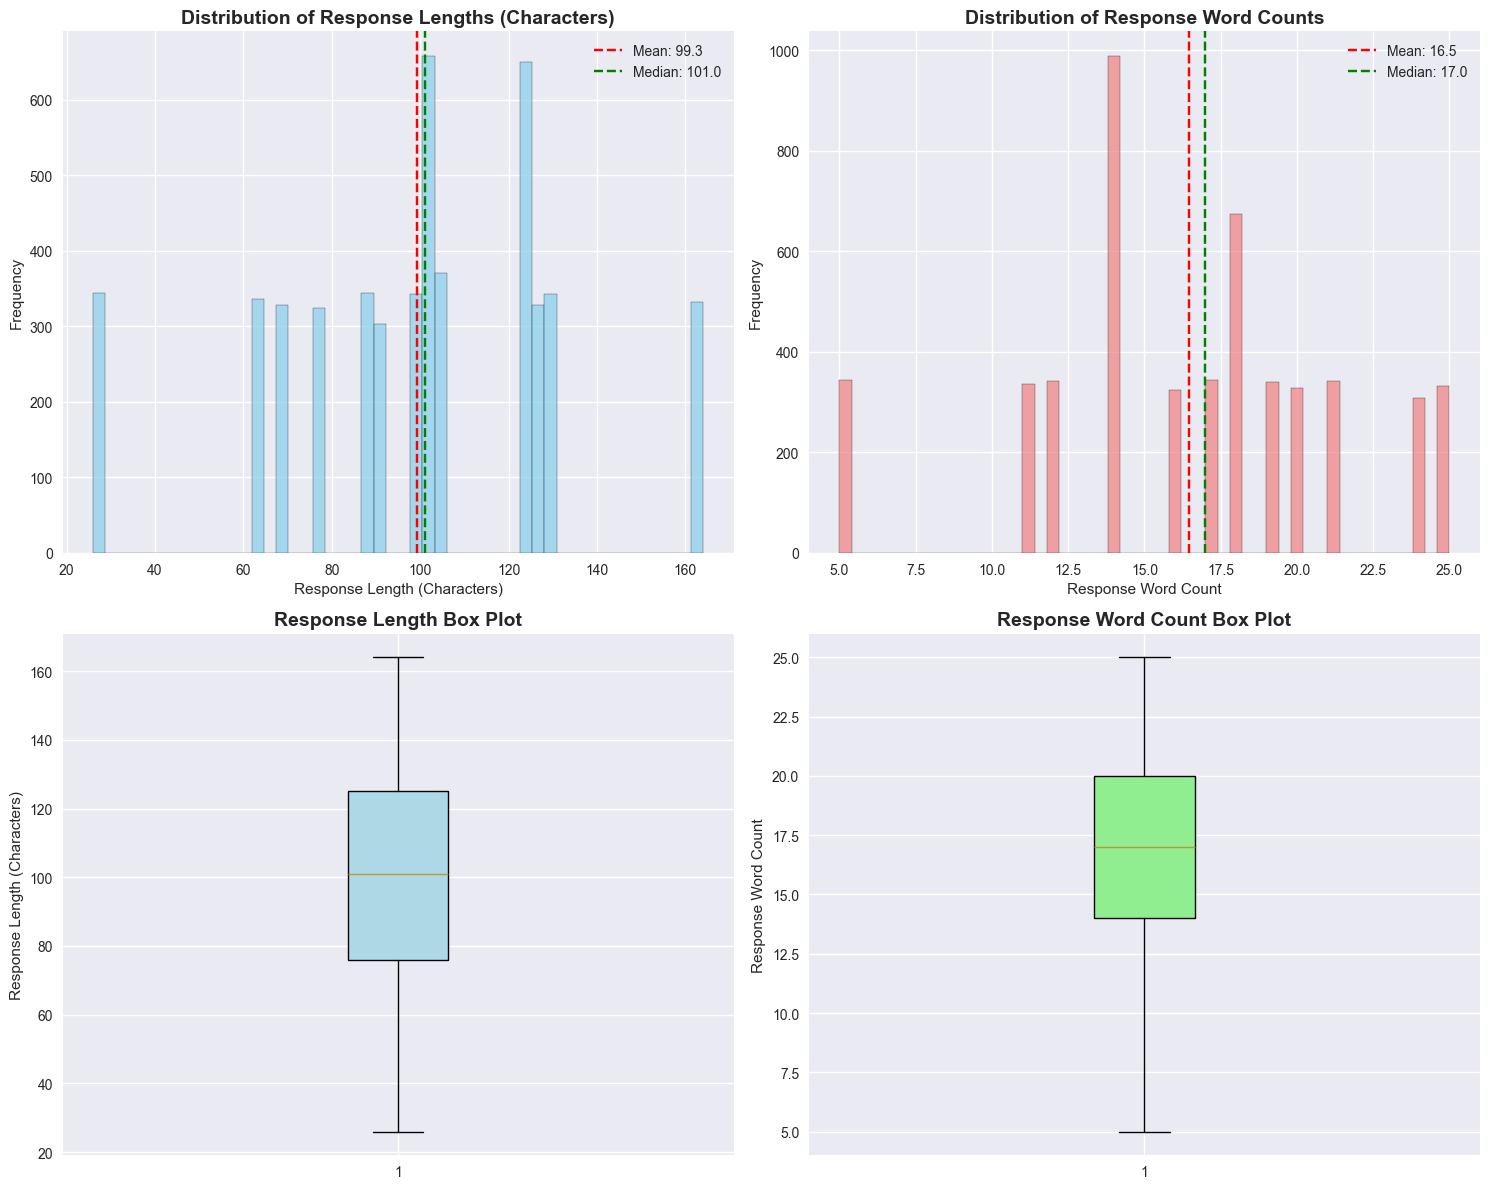

In [4]:
# Visualize response length distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Response length histogram
axes[0, 0].hist(df['Response_Length'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribution of Response Lengths (Characters)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Response Length (Characters)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(df['Response_Length'].mean(), color='red', linestyle='--', label=f'Mean: {df["Response_Length"].mean():.1f}')
axes[0, 0].axvline(df['Response_Length'].median(), color='green', linestyle='--', label=f'Median: {df["Response_Length"].median():.1f}')
axes[0, 0].legend()

# Response word count histogram
axes[0, 1].hist(df['Response_Word_Count'], bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
axes[0, 1].set_title('Distribution of Response Word Counts', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Response Word Count')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(df['Response_Word_Count'].mean(), color='red', linestyle='--', label=f'Mean: {df["Response_Word_Count"].mean():.1f}')
axes[0, 1].axvline(df['Response_Word_Count'].median(), color='green', linestyle='--', label=f'Median: {df["Response_Word_Count"].median():.1f}')
axes[0, 1].legend()

# Box plot for response lengths
axes[1, 0].boxplot(df['Response_Length'], patch_artist=True, boxprops=dict(facecolor='lightblue'))
axes[1, 0].set_title('Response Length Box Plot', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Response Length (Characters)')

# Box plot for response word counts
axes[1, 1].boxplot(df['Response_Word_Count'], patch_artist=True, boxprops=dict(facecolor='lightgreen'))
axes[1, 1].set_title('Response Word Count Box Plot', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Response Word Count')

plt.tight_layout()
plt.show()


Prompt Type Distribution:
Prompt_Type
Question      1670
Command       1670
Open-ended    1670
Name: count, dtype: int64

Percentage distribution:
Prompt_Type
Question      33.333333
Command       33.333333
Open-ended    33.333333
Name: proportion, dtype: float64


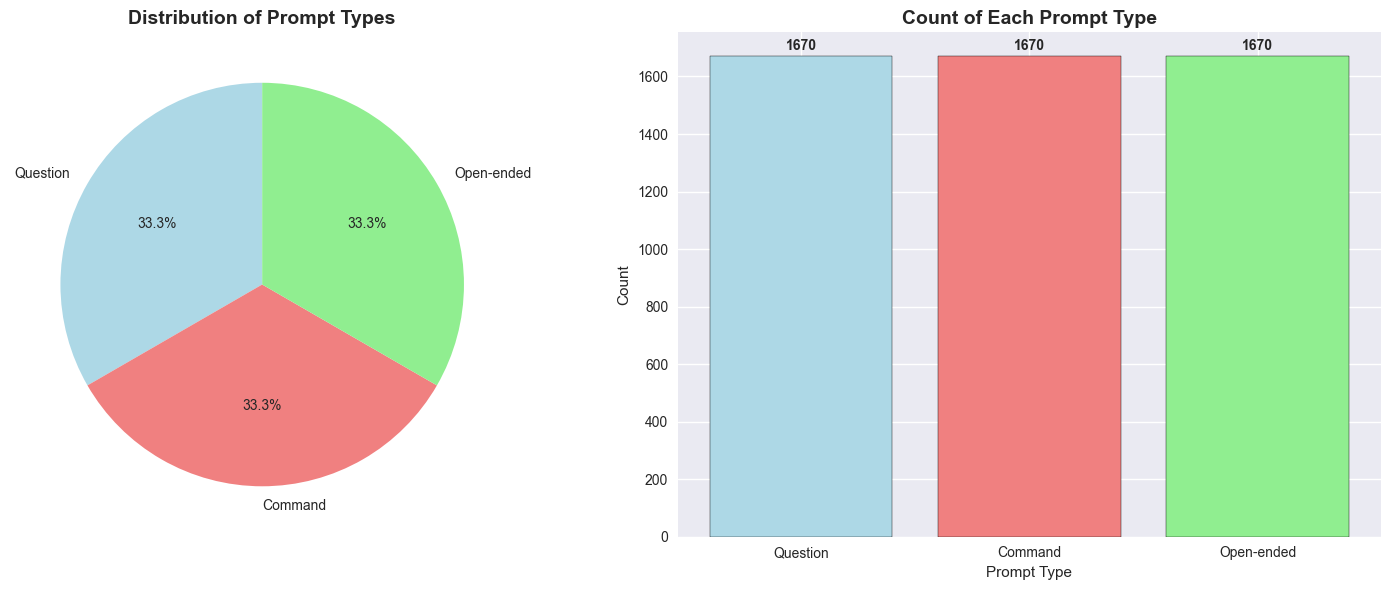

In [5]:
# Analyze prompt types distribution
print("Prompt Type Distribution:")
prompt_type_counts = df['Prompt_Type'].value_counts()
print(prompt_type_counts)
print(f"\nPercentage distribution:")
print(df['Prompt_Type'].value_counts(normalize=True) * 100)

# Visualize prompt type distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Pie chart for prompt types
axes[0].pie(prompt_type_counts.values, labels=prompt_type_counts.index, autopct='%1.1f%%', 
            colors=['lightblue', 'lightcoral', 'lightgreen'], startangle=90)
axes[0].set_title('Distribution of Prompt Types', fontsize=14, fontweight='bold')

# Bar chart for prompt types
bars = axes[1].bar(prompt_type_counts.index, prompt_type_counts.values, 
                   color=['lightblue', 'lightcoral', 'lightgreen'], edgecolor='black')
axes[1].set_title('Count of Each Prompt Type', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Prompt Type')
axes[1].set_ylabel('Count')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 10,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


Response Length Statistics by Prompt Type:
             count    mean  median    std  min  max
Prompt_Type                                        
Command       1670  124.65   128.0  27.86   76  164
Open-ended    1670   92.53   101.0  22.42   64  125
Question      1670   80.61    90.0  28.30   26  102


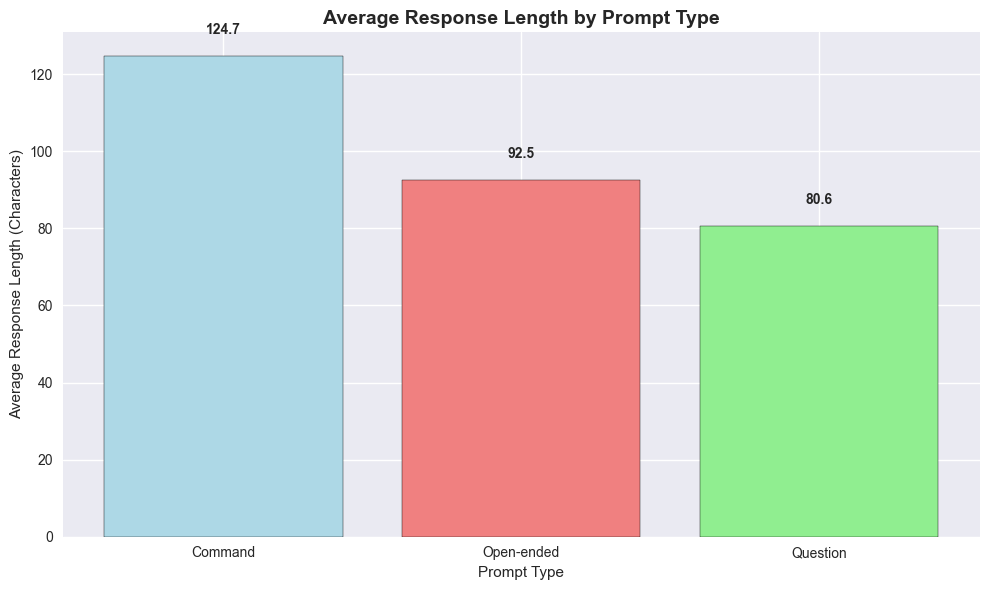

In [17]:
# Analyze response lengths by prompt type
print("Response Length Statistics by Prompt Type:")
response_stats_by_type = df.groupby('Prompt_Type')['Response_Length'].agg(['count', 'mean', 'median', 'std', 'min', 'max'])
print(response_stats_by_type.round(2))

# Average response length by prompt type
avg_response_by_type = df.groupby('Prompt_Type')['Response_Length'].mean()

# Create bar chart for average response length by prompt type
plt.figure(figsize=(10, 6))
bars = plt.bar(avg_response_by_type.index, avg_response_by_type.values,
               color=['lightblue', 'lightcoral', 'lightgreen'], edgecolor='black')
plt.title('Average Response Length by Prompt Type', fontsize=14, fontweight='bold')
plt.xlabel('Prompt Type')
plt.ylabel('Average Response Length (Characters)')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{height:.1f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


Correlation Analysis:
                     Prompt_Length  Response_Length  Response_Word_Count  \
Prompt_Length                1.000            0.415                0.153   
Response_Length              0.415            1.000                0.915   
Response_Word_Count          0.153            0.915                1.000   
Prompt_Word_Count            0.769            0.135               -0.001   

                     Prompt_Word_Count  
Prompt_Length                    0.769  
Response_Length                  0.135  
Response_Word_Count             -0.001  
Prompt_Word_Count                1.000  


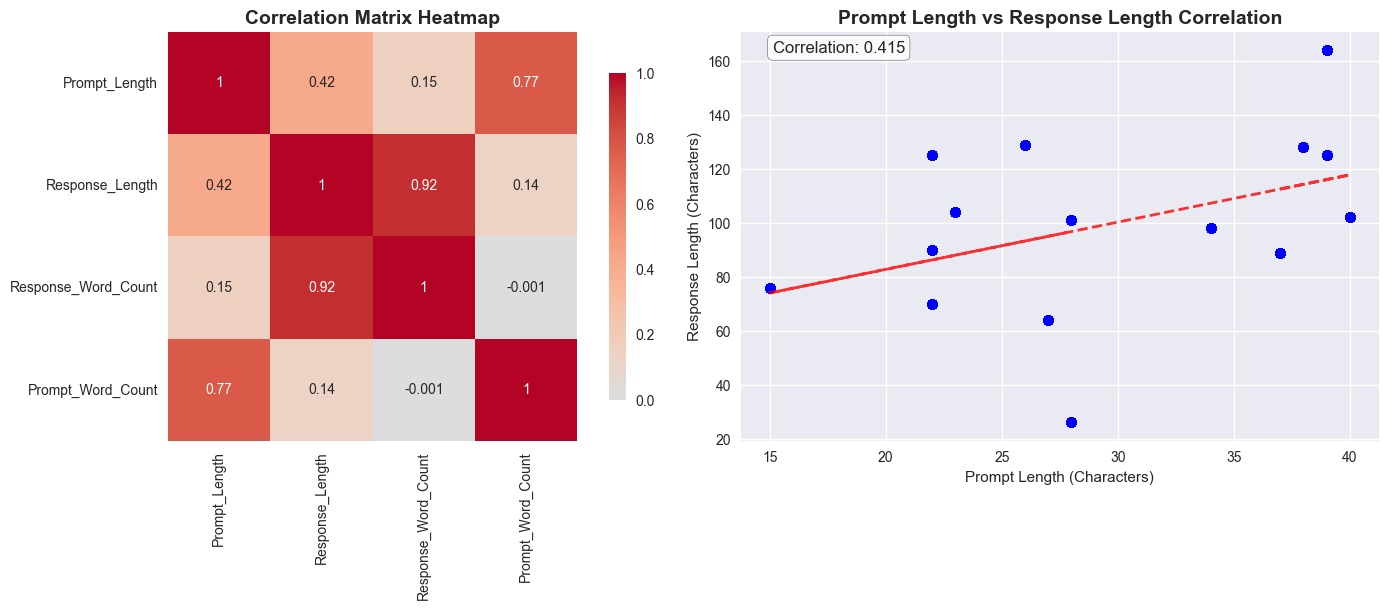

In [7]:
# Correlation analysis
print("Correlation Analysis:")
correlation_matrix = df[['Prompt_Length', 'Response_Length', 'Response_Word_Count', 'Prompt_Word_Count']].corr()
print(correlation_matrix.round(3))

# Visualize correlation matrix
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Heatmap of correlations
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, ax=axes[0], cbar_kws={'shrink': 0.8})
axes[0].set_title('Correlation Matrix Heatmap', fontsize=14, fontweight='bold')

# Scatter plot matrix for key relationships
axes[1].scatter(df['Prompt_Length'], df['Response_Length'], alpha=0.5, color='blue')
axes[1].set_xlabel('Prompt Length (Characters)')
axes[1].set_ylabel('Response Length (Characters)')
axes[1].set_title('Prompt Length vs Response Length Correlation', fontsize=14, fontweight='bold')

# Add trend line
z = np.polyfit(df['Prompt_Length'], df['Response_Length'], 1)
p = np.poly1d(z)
axes[1].plot(df['Prompt_Length'], p(df['Prompt_Length']), "r--", alpha=0.8, linewidth=2)

# Calculate and display correlation coefficient
correlation = df['Prompt_Length'].corr(df['Response_Length'])
axes[1].text(0.05, 0.95, f'Correlation: {correlation:.3f}', 
             transform=axes[1].transAxes, fontsize=12, 
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.show()


Word Count Analysis:
Average words per prompt: 5.14
Average words per response: 16.48
Ratio of response words to prompt words: 3.21


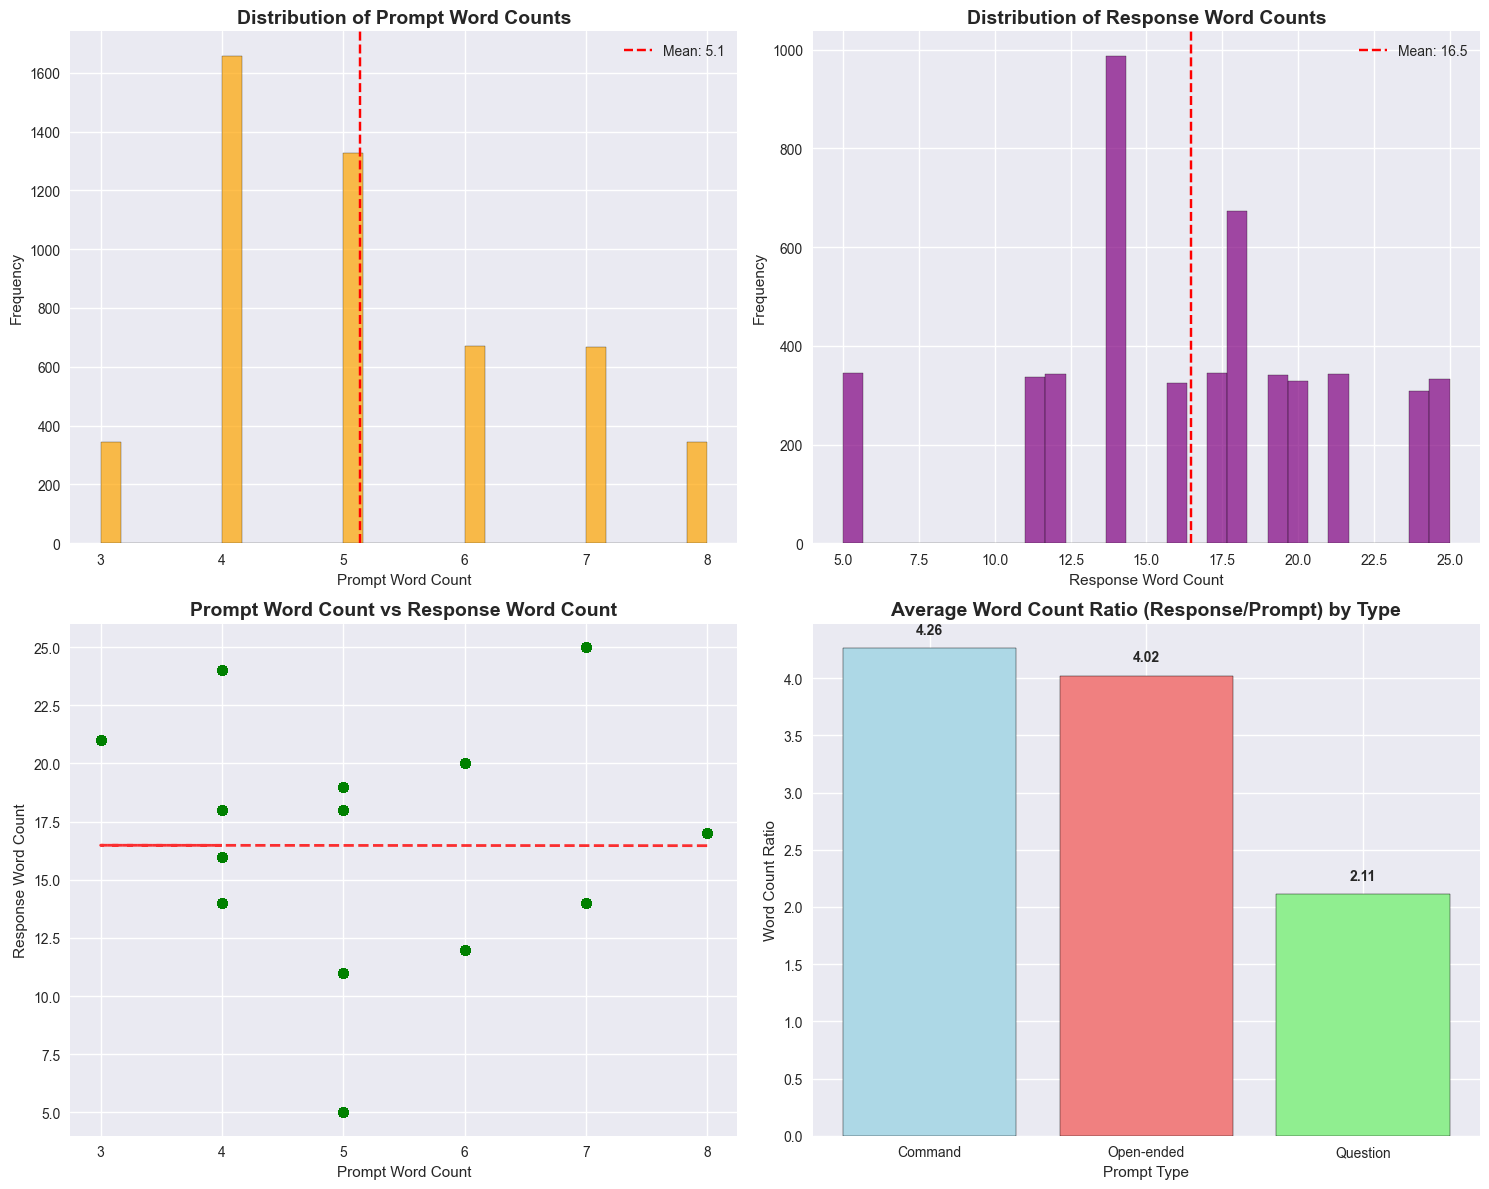

In [8]:
# Word count analysis and visualizations
print("Word Count Analysis:")
print(f"Average words per prompt: {df['Prompt_Word_Count'].mean():.2f}")
print(f"Average words per response: {df['Response_Word_Count'].mean():.2f}")
print(f"Ratio of response words to prompt words: {df['Response_Word_Count'].mean() / df['Prompt_Word_Count'].mean():.2f}")

# Visualize word count distributions
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Prompt word count distribution
axes[0, 0].hist(df['Prompt_Word_Count'], bins=30, alpha=0.7, color='orange', edgecolor='black')
axes[0, 0].set_title('Distribution of Prompt Word Counts', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Prompt Word Count')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(df['Prompt_Word_Count'].mean(), color='red', linestyle='--', 
                  label=f'Mean: {df["Prompt_Word_Count"].mean():.1f}')
axes[0, 0].legend()

# Response word count distribution
axes[0, 1].hist(df['Response_Word_Count'], bins=30, alpha=0.7, color='purple', edgecolor='black')
axes[0, 1].set_title('Distribution of Response Word Counts', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Response Word Count')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(df['Response_Word_Count'].mean(), color='red', linestyle='--', 
                  label=f'Mean: {df["Response_Word_Count"].mean():.1f}')
axes[0, 1].legend()

# Scatter plot: Prompt words vs Response words
axes[1, 0].scatter(df['Prompt_Word_Count'], df['Response_Word_Count'], alpha=0.6, color='green')
axes[1, 0].set_title('Prompt Word Count vs Response Word Count', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Prompt Word Count')
axes[1, 0].set_ylabel('Response Word Count')

# Add trend line
z = np.polyfit(df['Prompt_Word_Count'], df['Response_Word_Count'], 1)
p = np.poly1d(z)
axes[1, 0].plot(df['Prompt_Word_Count'], p(df['Prompt_Word_Count']), "r--", alpha=0.8, linewidth=2)

# Word count ratio by prompt type
word_ratio = df['Response_Word_Count'] / df['Prompt_Word_Count']
df['Word_Ratio'] = word_ratio

ratio_by_type = df.groupby('Prompt_Type')['Word_Ratio'].mean()
bars = axes[1, 1].bar(ratio_by_type.index, ratio_by_type.values,
                      color=['lightblue', 'lightcoral', 'lightgreen'], edgecolor='black')
axes[1, 1].set_title('Average Word Count Ratio (Response/Prompt) by Type', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Prompt Type')
axes[1, 1].set_ylabel('Word Count Ratio')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 0.1,
                    f'{height:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


In [9]:
# Summary statistics and insights
print("="*60)
print("DATASET ANALYSIS SUMMARY")
print("="*60)

print(f"\n📊 Dataset Overview:")
print(f"   • Total samples: {len(df):,}")
print(f"   • Unique prompts: {df['Prompt'].nunique():,}")
print(f"   • Unique responses: {df['Response'].nunique():,}")

print(f"\n📝 Prompt Analysis:")
print(f"   • Average prompt length: {df['Prompt_Length'].mean():.1f} characters")
print(f"   • Average prompt word count: {df['Prompt_Word_Count'].mean():.1f} words")
print(f"   • Prompt type distribution:")
for ptype, count in df['Prompt_Type'].value_counts().items():
    percentage = (count / len(df)) * 100
    print(f"     - {ptype}: {count:,} ({percentage:.1f}%)")

print(f"\n💬 Response Analysis:")
print(f"   • Average response length: {df['Response_Length'].mean():.1f} characters")
print(f"   • Average response word count: {df['Response_Word_Count'].mean():.1f} words")
print(f"   • Shortest response: {df['Response_Length'].min()} characters")
print(f"   • Longest response: {df['Response_Length'].max()} characters")

print(f"\n🔗 Relationships:")
correlation = df['Prompt_Length'].corr(df['Response_Length'])
print(f"   • Prompt-Response length correlation: {correlation:.3f}")
word_correlation = df['Prompt_Word_Count'].corr(df['Response_Word_Count'])
print(f"   • Prompt-Response word count correlation: {word_correlation:.3f}")

print(f"\n📈 Key Insights:")
print(f"   • Response expansion ratio: {df['Response_Word_Count'].mean() / df['Prompt_Word_Count'].mean():.2f}x")
print(f"   • Most common prompt type: {df['Prompt_Type'].mode().iloc[0]}")
print(f"   • Response length varies significantly by prompt type")

print("\n" + "="*60)


DATASET ANALYSIS SUMMARY

📊 Dataset Overview:
   • Total samples: 5,010
   • Unique prompts: 15
   • Unique responses: 15

📝 Prompt Analysis:
   • Average prompt length: 29.4 characters
   • Average prompt word count: 5.1 words
   • Prompt type distribution:
     - Question: 1,670 (33.3%)
     - Command: 1,670 (33.3%)
     - Open-ended: 1,670 (33.3%)

💬 Response Analysis:
   • Average response length: 99.3 characters
   • Average response word count: 16.5 words
   • Shortest response: 26 characters
   • Longest response: 164 characters

🔗 Relationships:
   • Prompt-Response length correlation: 0.415
   • Prompt-Response word count correlation: -0.001

📈 Key Insights:
   • Response expansion ratio: 3.21x
   • Most common prompt type: Command
   • Response length varies significantly by prompt type

